# Unit 10 Artefact 2: Designing a DR Solution for Pampered Pets against RPO and RTO Requirements

Ian Stevens, Security and Risk Management, Unit 10.

Unit 9 ended with a business impact analysis (BIA) that set an RTO and an RPO for each Pampered Pets function, and with backup and restore as the cheapest recovery tier for the online shop. This notebook takes the next step the unit asks for: designing a solution that meets a set of RPO and RTO requirements. It does four things.

1. It checks the cost model in the required reading, Alhazmi and Malaiya (2013), before using it.
2. It maps the online order process as a mission thread (Corbari et al., 2024) to find which systems recovery depends on and who controls them.
3. It compares six designs against four kinds of event, including the two that Unit 9 did not model: an outage of the whole provider and the loss of the account itself.
4. It measures each design against the requirements and costs it with Alhazmi and Malaiya's equations, corrected where Section 1 shows they need it.

Every figure is an assumption made for this exercise. The case study gives no turnover, order volumes or IT costs, and 'provider A' and 'provider B' are placeholders, not products. The business inputs are the same as in Unit 9 so the two notebooks can be compared.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(2026)
N = 20_000
pd.set_option("display.width", 170); pd.set_option("display.max_colwidth", 70)
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#8a8984", "axes.labelcolor": "#0b0b0b",
    "xtick.color": "#52514e", "ytick.color": "#52514e",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e4e3df", "grid.linewidth": 0.8,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
    "lines.linewidth": 2,
})
BLUE, ORANGE, AQUA, VIOLET, INK, RED = "#2a78d6", "#eb6834", "#1baf7a", "#7c5cd6", "#52514e", "#c23b3b"
tri = lambda a, m, b, n=N: rng.triangular(a, m, b, n)

def tri_q(u, a, m, c):
    # inverse CDF of the triangular distribution, so every design uses the same uniform draws
    if c == a:
        return np.full_like(u, a, dtype=float)
    f = (m - a) / (c - a)
    return np.where(u < f, a + np.sqrt(u * (c - a) * (m - a)), c - np.sqrt((1 - u) * (c - a) * (c - m)))

## 1. Checking Alhazmi and Malaiya's model

The paper offers a framework, not results, so there is nothing to reproduce in the Unit 9 sense. What can be checked is whether its tables and equations are consistent with each other and with what the text says about them.

### 1.1 The recovery tiers (Table 2)

The text says a higher tier 'would exponentially reduce RTO'. Table 2, which the authors take from Wiboonratr and Kosavisutte (2009, cited in Alhazmi and Malaiya, 2013), can be plotted to see whether it does.

In [2]:
tiers = pd.DataFrame([
    (1, "Point in time tape backup", 48, 168, 2, 24),
    (2, "Tape backup to remote site", 24, 72, 2, 24),
    (3, "Disk point in time copy", 2, 24, 2, 24),
    (4, "Remote logging", 12, 24, 5/60, 0.5),
    (5, "Concurrent ReEx", 1, 12, 5/60, 10/60),
    (6, "Mirrored data", 1, 4, 0, 5/60),
    (7, "Mirrored data with failover", 0, 1, 0, 5/60),
], columns=["tier", "description", "rto_min_h", "rto_max_h", "rpo_min_h", "rpo_max_h"]).set_index("tier")
print(tiers.round(3).to_string())
print()
print("Tiers whose best-case RTO is worse than the tier below:",
      [t for t in tiers.index[1:] if tiers.rto_min_h[t] > tiers.rto_min_h[t - 1]])
print("Tiers with an identical RPO range:", [t for t in tiers.index if (tiers.rpo_min_h[t], tiers.rpo_max_h[t]) == (2, 24)])

                      description  rto_min_h  rto_max_h  rpo_min_h  rpo_max_h
tier                                                                         
1       Point in time tape backup         48        168      2.000     24.000
2      Tape backup to remote site         24         72      2.000     24.000
3         Disk point in time copy          2         24      2.000     24.000
4                  Remote logging         12         24      0.083      0.500
5                 Concurrent ReEx          1         12      0.083      0.167
6                   Mirrored data          1          4      0.000      0.083
7     Mirrored data with failover          0          1      0.000      0.083

Tiers whose best-case RTO is worse than the tier below: [4]
Tiers with an identical RPO range: [1, 2, 3]


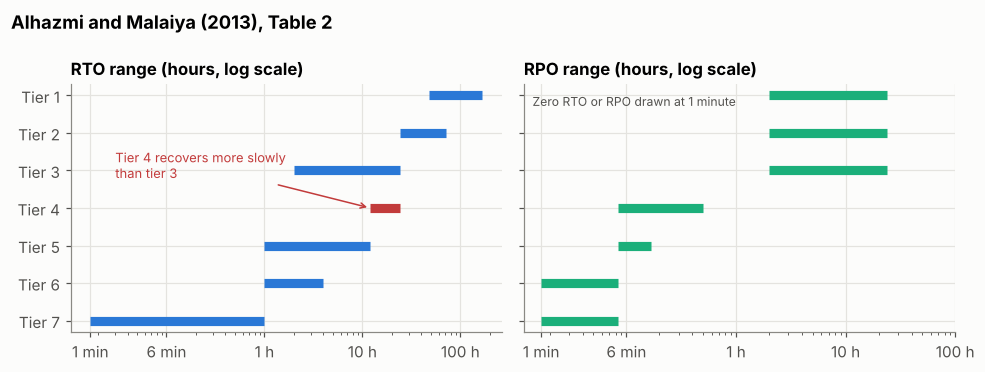

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(9, 3.4), sharey=True)
floor = 1 / 60
for t, r in tiers.iterrows():
    ax[0].plot([max(r.rto_min_h, floor), r.rto_max_h], [t, t], color=RED if t == 4 else BLUE, lw=6, solid_capstyle="butt")
    ax[1].plot([max(r.rpo_min_h, floor), r.rpo_max_h], [t, t], color=AQUA, lw=6, solid_capstyle="butt")
for a, title in zip(ax, ["RTO range (hours, log scale)", "RPO range (hours, log scale)"]):
    a.set_xscale("log"); a.set_title(title, loc="left"); a.set_xticks([1/60, 0.1, 1, 10, 100], ["1 min", "6 min", "1 h", "10 h", "100 h"])
ax[0].set_yticks(tiers.index, [f"Tier {t}" for t in tiers.index]); ax[0].invert_yaxis()
ax[0].annotate("Tier 4 recovers more slowly\nthan tier 3", xy=(12, 4), xytext=(0.03, 3.2), fontsize=8.5, color=RED,
               arrowprops=dict(arrowstyle="->", color=RED, lw=1))
ax[1].text(0.02, 0.96, "Zero RTO or RPO drawn at 1 minute", transform=ax[1].transAxes, fontsize=8, color=INK, va="top")
fig.suptitle("Alhazmi and Malaiya (2013), Table 2", x=0.01, ha="left", fontweight="bold")
fig.tight_layout()
fig.savefig("figures/u10_tiers.png", dpi=150, bbox_inches="tight")

The tiers do not fall steadily. Tier 4 (remote logging) has a slower RTO than tier 3, and tiers 1 to 3 have the same RPO, so moving up the first three tiers buys recovery time but no data. The paper also says tiers are 'not standard' and that the terms 'hot' and 'warm' are defined differently by different vendors, which is a reason to state an RTO and RPO for each design instead of a tier name. The text has one slip that matters for a reader: 'if the desired RTO is low as in tier 1' should read high.

### 1.2 The annual cost of disasters (Equation 3)

The total annual cost is $C_T = C_i + C_o + C_d$ (Eq. 1). For each disaster type $i$ with probability $p_i$, the paper gives

$$C_d = \sum_i p_i\,(C_{r,i} + C_{u,i})$$

where $C_r$ is the cost of a recovery and $C_u$ the cost of a disaster that cannot be recovered. Read literally, every disaster incurs both. A disaster is either recovered or it is not, so the expected cost should weight the two by the probability $u_i$ that recovery fails:

$$C_d = \sum_i p_i\,\big[(1-u_i)\,C_{r,i} + u_i\,C_{u,i}\big]$$

In [4]:
# Two designs facing one disaster type, p = 0.05 a year. A cannot recover (u = 1); B always can (u = 0).
p, Cr, Cu = 0.05, 2_000, 50_000
for name, u, Ci_Co in [("A: no independent copy", 1.0, 100), ("B: independent copy", 0.0, 1_000)]:
    printed = Ci_Co + p * (Cr + Cu)
    corrected = Ci_Co + p * ((1 - u) * Cr + u * Cu)
    print(f"{name:24s} Eq. 3 as printed: £{printed:>6,.0f}   corrected: £{corrected:>6,.0f}")

A: no independent copy   Eq. 3 as printed: £ 2,700   corrected: £ 2,600
B: independent copy      Eq. 3 as printed: £ 3,600   corrected: £ 1,100


As printed, Equation 3 charges both designs for the unrecoverable disaster, so B's only advantage, that it can recover, disappears and the cheaper design A always wins. Section 6 repeats this test on the full model.

### 1.3 The cost of downtime (Table 3)

Table 3 lists revenue lost per hour of downtime by industry in 2000, with retail at \$1,107,274 an hour. The paper says actual values 'would need to be estimated for a specific organization', which is the right caveat, but the table is the only cost input it gives. The citation is also shifted: Table 3 and the claim about backup overhead are both credited to reference 15 (a vendor web page), while reference 16 (Meta Group, October 2000), which looks like the real source of the table, and reference 14 (Chandy et al., 1975, on rollback and recovery) are never cited at all.

In [5]:
b = pd.DataFrame(dict(
    turnover=tri(250_000, 450_000, 900_000),
    online_share=tri(0.10, 0.25, 0.50),
    lost_fraction=tri(0.2, 0.5, 0.9),        # share of online sales during an outage that never return
    peak_factor=tri(1.0, 1.5, 3.0),          # outages tend to be noticed in busy hours
    order_value=tri(25, 40, 70),
    cost_per_lost_order=tri(20, 50, 150),    # refund, re-contact and goodwill for an order whose record is lost
    psp_recovery=tri(0.5, 0.8, 0.95),        # share of lost paid orders that can be re-keyed from the payment provider's records
    unrecoverable=tri(15_000, 50_000, 200_000),  # rebuild customer and order records, notify customers and the ICO, reputation
    day_rate=tri(250, 400, 600),             # cost of a person-day of IT work, internal or bought in
))
b["online_sales"] = b.turnover * b.online_share
b["cost_per_hour"] = b.online_sales / 8760 * b.lost_fraction * b.peak_factor
b["orders_per_hour"] = b.online_sales / b.order_value / 8760
b["cost_per_data_hour"] = b.orders_per_hour * b.cost_per_lost_order * (1 - b.psp_recovery)
print(f"Pampered Pets, modelled cost of an hour of online downtime: median £{b.cost_per_hour.median():,.2f} "
      f"(5th-95th percentile £{b.cost_per_hour.quantile(.05):,.2f}-£{b.cost_per_hour.quantile(.95):,.2f})")
print(f"Online orders per hour: median {b.orders_per_hour.median():.2f}")
print(f"Table 3, retail, 2000: $1,107,274 an hour, about {1_107_274 / b.cost_per_hour.median():,.0f} times the median (ignoring the currency)")

Pampered Pets, modelled cost of an hour of online downtime: median £14.74 (5th-95th percentile £5.78-£34.77)
Online orders per hour: median 0.37
Table 3, retail, 2000: $1,107,274 an hour, about 75,139 times the median (ignoring the currency)


## 2. The requirements

The RTOs and RPOs come from the Unit 9 BIA for the online shop (F2) and the customer and order data (F3). Two changes follow from Unit 9's conclusions: a separate RPO for data disasters, because replication copies corruption, and two design rules that a requirement expressed only in hours would miss.

In [6]:
REQ = dict(RTO=36.0, RPO_infra=0.25, RPO_data=24.0)
requirements = pd.DataFrame([
    ("R1", "RTO for the online shop and order data", "36 h", "Unit 9 BIA: MTPD 72 h, RTO at most half"),
    ("R2", "RPO after an infrastructure event (outage, account loss)", "15 min", "Unit 9 BIA for F3"),
    ("R3", "RPO after a data disaster (ransomware, deletion, corruption)", "24 h", "New: replication is not a backup"),
    ("R4", "At least one copy that production admin credentials cannot delete", "rule", "NCSC (2019); Unit 9"),
    ("R5", "Restore tested end to end at least twice a year", "rule", "Unit 9: trust an RTO only once tested"),
], columns=["id", "requirement", "target", "source"]).set_index("id")
print(requirements.to_string())

                                                          requirement  target                                   source
id                                                                                                                    
R1                             RTO for the online shop and order data    36 h  Unit 9 BIA: MTPD 72 h, RTO at most half
R2           RPO after an infrastructure event (outage, account loss)  15 min                        Unit 9 BIA for F3
R3       RPO after a data disaster (ransomware, deletion, corruption)    24 h         New: replication is not a backup
R4  At least one copy that production admin credentials cannot delete    rule                      NCSC (2019); Unit 9
R5                    Restore tested end to end at least twice a year    rule    Unit 9: trust an RTO only once tested


## 3. Mission thread: what does taking an online order depend on?

Corbari et al. (2024) separate a **mission process thread** (the steps of the mission, set by the people who own it) from the **mission engineering threads** (the systems and data paths that carry each step, across the physical, logical and persona layers of cyberspace). Their main argument is that protection should cover the 'mission relevant terrain' an organisation *uses*, not only what it *owns*, because the terrain 'may exist external to' its own network. For a small business that rents almost everything, that is most of it.

The mission here is 'take and fulfil an online order'. The process steps follow the digitalised data flow in our team report (Group 2, 2025); the components and their owners are my assumptions for the design in the executive summary, which put the shop on a single cloud provider (Stevens, 2026).

In [7]:
steps = ["S1 Customer reaches the shop", "S2 Browses and places order", "S3 Pays",
         "S4 Order and customer recorded", "S5 Picked and dispatched", "S6 Customer and supplier notified"]
components = pd.DataFrame([
    ("C1", "Domain and DNS",              "logical", "Registrar"),
    ("C2", "Shop application",            "logical", "Provider A"),
    ("C3", "Order and customer database", "logical", "Provider A"),
    ("C4", "Hosted payment page, card tokens", "logical", "Payment provider"),
    ("C5", "Stock and ERP service",       "logical", "SaaS vendor"),
    ("C6", "Courier label service",       "logical", "Courier"),
    ("C7", "Email",                       "logical", "Provider A"),
    ("C8", "Admin and staff identities (MFA)", "persona", "Provider A"),
    ("C9", "Warehouse PC and broadband",  "physical", "Pampered Pets"),
    ("C10", "Staff phones (MFA codes)",   "persona/physical", "Staff (own devices)"),
], columns=["id", "component", "layer", "controlled by"]).set_index("id")
uses = {  # mission engineering threads: which components each step needs
    0: ["C1", "C2"],
    1: ["C1", "C2", "C3"],
    2: ["C2", "C4"],
    3: ["C2", "C3", "C8"],
    4: ["C3", "C5", "C6", "C8", "C9", "C10"],
    5: ["C7", "C8", "C10"],
}
M = pd.DataFrame(0, index=steps, columns=components.index)
for i, cs in uses.items():
    M.loc[steps[i], cs] = 1
print(components.to_string()); print()
owners = components["controlled by"]
for o in owners.unique():
    cs = owners.index[owners == o]
    hit = [s[:2] for s in steps if M.loc[s, cs].any()]
    print(f"{o:20s} controls {len(cs)} component(s); steps that stop if it fails: {', '.join(hit)}")
print(f"\nSteps that need nothing from provider A: {[s[:2] for s in steps if not M.loc[s, owners.index[owners == 'Provider A']].any()]}")

                            component             layer        controlled by
id                                                                          
C1                     Domain and DNS           logical            Registrar
C2                   Shop application           logical           Provider A
C3        Order and customer database           logical           Provider A
C4   Hosted payment page, card tokens           logical     Payment provider
C5              Stock and ERP service           logical          SaaS vendor
C6              Courier label service           logical              Courier
C7                              Email           logical           Provider A
C8   Admin and staff identities (MFA)           persona           Provider A
C9         Warehouse PC and broadband          physical        Pampered Pets
C10          Staff phones (MFA codes)  persona/physical  Staff (own devices)

Registrar            controls 1 component(s); steps that stop if it fails: 

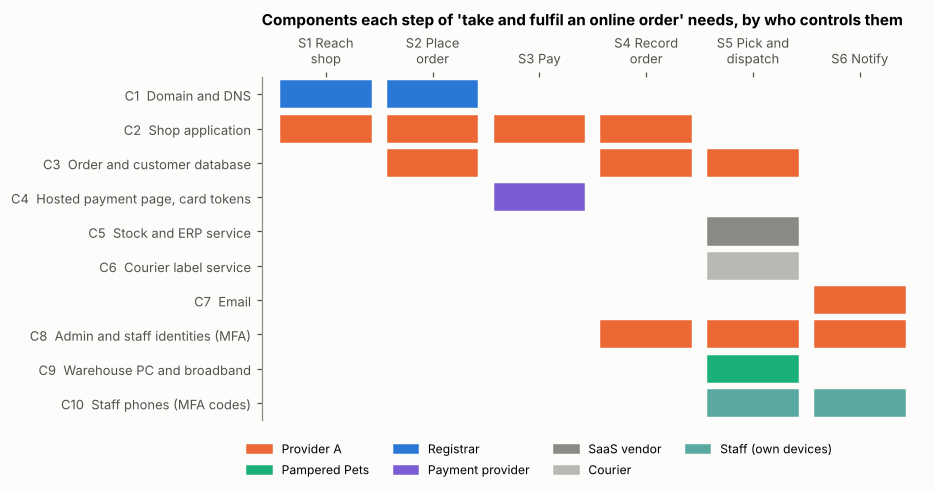

In [8]:
OWNER_COL = {"Provider A": ORANGE, "Pampered Pets": AQUA, "Registrar": BLUE, "Payment provider": VIOLET,
             "SaaS vendor": "#8a8984", "Courier": "#b9b8b2", "Staff (own devices)": "#5aa9a0"}
fig, ax = plt.subplots(figsize=(8.6, 4.6))
short = ["S1 Reach\nshop", "S2 Place\norder", "S3 Pay", "S4 Record\norder", "S5 Pick and\ndispatch", "S6 Notify"]
for i, s in enumerate(steps):
    for j, c in enumerate(components.index):
        if M.loc[s, c]:
            ax.add_patch(plt.Rectangle((i - 0.42, j - 0.38), 0.84, 0.76, color=OWNER_COL[owners[c]]))
ax.set_ylim(len(components) - 0.5, -0.5); ax.set_xlim(-0.6, len(steps) - 0.4)
ax.set_yticks(range(len(components)), [f"{c}  {components.component[c]}" for c in components.index], fontsize=8.5)
ax.set_xticks(range(len(steps)), short, fontsize=8.5); ax.xaxis.tick_top(); ax.grid(False)
ax.spines["bottom"].set_visible(False); ax.spines["top"].set_visible(False)
handles = [plt.Rectangle((0, 0), 1, 1, color=v) for v in OWNER_COL.values()]
ax.legend(handles, OWNER_COL.keys(), ncol=4, fontsize=8, loc="upper center", bbox_to_anchor=(0.42, -0.03), frameon=False)
ax.set_title("Components each step of 'take and fulfil an online order' needs, by who controls them", loc="left", fontsize=10, pad=34)
fig.tight_layout()
fig.savefig("figures/u10_mission_thread.png", dpi=150, bbox_inches="tight")

Every one of the six steps needs provider A, and only one component (the warehouse PC) is under Pampered Pets' own control. Three findings shape the designs below.

* **Identity is the hidden single point.** The admin and staff identities (C8) sit with provider A, so an outage of A's identity service, or the loss of the account, locks staff out of email and the order data at the same time as the shop goes down. A copy elsewhere is only usable if it can be reached with credentials that do not depend on A.
* **DNS must stay outside A.** Failing over to another provider means pointing the domain somewhere else. If the domain's DNS were hosted by A, an outage of A or the loss of the account would also remove the means of moving away from it. This is Kumar's (2024) 'network lock-in' in its most practical form.
* **The payment provider is already an independent record.** Every paid order exists at the payment provider (C4) as well as in the shop database. That is why lost paid orders can be partly re-keyed (`psp_recovery`), and it gives a cheap way to detect missing or altered orders (Section 7).

## 4. Events and candidate designs

Unit 9 modelled infrastructure disasters and data disasters. The mission thread shows that two infrastructure events behave differently from a regional outage, because they hit every region of provider A at once: a provider-wide outage (a control-plane, identity or faulty-update failure, like the CrowdStrike and us-east-1 events discussed in Unit 9 (Microsoft, 2024; AWS, 2025)) and the loss of the account itself. In May 2024 Google Cloud deleted UniSuper's private cloud subscription because of a blank parameter in an internal tool. The deletion went 'across both' of the geographies UniSuper used for redundancy, and recovery depended on backups that survived the deletion (UniSuper and Google Cloud, 2024; Google Cloud, 2024).

In [9]:
ev = pd.DataFrame(dict(
    E1_rate=tri(0.10, 0.30, 1.00), E1_dur=tri(1, 6, 24),       # outage of one region of provider A (hours)
    E2_rate=tri(0.02, 0.08, 0.30), E2_dur=tri(2, 10, 48),      # outage of provider A in every region
    E3_rate=tri(0.02, 0.06, 0.20),                             # data disaster through the admin plane
    E3_detect=tri(0.5, 4, 72),                                 # hours before the corruption or deletion is noticed
    E3_wipe=tri(0.3, 0.6, 0.9),                                # P(backups that admin credentials can delete are also lost)
    E4_rate=tri(0.002, 0.01, 0.03),                            # loss of the whole account at provider A
))
EVENTS = {"E1": "Regional outage", "E2": "Provider-wide outage", "E3": "Data disaster", "E4": "Account loss"}
print(ev.describe(percentiles=[.5]).T[["min", "50%", "max"]].round(3).to_string())

             min     50%     max
E1_rate    0.100   0.440   0.996
E1_dur     1.034   9.506  23.922
E2_rate    0.020   0.125   0.298
E2_dur     2.138  18.366  47.559
E3_rate    0.021   0.087   0.198
E3_detect  0.556  22.909  71.871
E3_wipe    0.303   0.599   0.898
E4_rate    0.002   0.013   0.030


In [10]:
designs = pd.DataFrame([
    ("D1", "Provider defaults", "One region, zone-redundant; the provider's automated backups in the same account"),
    ("D2", "Active-active in A", "The executive summary's design: two regions of A, continuous replication; backups as D1"),
    ("D3", "Backup and restore in A", "Hourly copies to a second region of A and a daily copy in an immutable vault in the same account"),
    ("D4", "D3 + independent copy at B", "D3 plus exports every 15 minutes, in open formats, to provider B under separate credentials; "
                                         "infrastructure as code for B; restore tested twice a year"),
    ("D5", "DRaaS vendor", "A third party replicates continuously to its own cloud and fails over on request; journal of recovery points"),
    ("D6", "Multi-cloud active-active", "Live in both A and B with continuous replication and separate credentials (Kumar's multi-cloud)"),
], columns=["id", "design", "description"]).set_index("id")
print(designs.to_string())

                        design                                                                                                                                             description
id                                                                                                                                                                                    
D1           Provider defaults                                                                        One region, zone-redundant; the provider's automated backups in the same account
D2          Active-active in A                                                                 The executive summary's design: two regions of A, continuous replication; backups as D1
D3     Backup and restore in A                                                        Hourly copies to a second region of A and a daily copy in an immutable vault in the same account
D4  D3 + independent copy at B  D3 plus exports every 15 minutes, in open formats, to

## 5. The model

**Recovery time.** Alhazmi and Malaiya's Equation 4 builds the RTO from the steps a recovery has to perform: $RTO = \text{fraction of } RPO + \sum_{j=j_{min}}^{5} T_j$, where $T_1$ to $T_5$ are hardware set-up, operating system, application, data restoration and readiness checks with IP switching, and $j_{min}$ depends on how ready the standby is. In the cloud $T_2$ is part of $T_1$. I add the time to notice and declare a disaster, which their definition of RTO includes, and their 'fraction of RPO' becomes the time to re-key lost orders.

**Backup reliability.** The paper assumes that 'backup reliability is 1'. Here an untested restore fails the first time with probability 10-40% and a tested one with 2-10%, and a failure multiplies the recovery time by 1.5 to 3.

**When to invoke.** Invoking a manual plan has a cost: the copy is older than the live data. The plan therefore waits for the provider until the latest start that still leaves time to meet the RTO, and recovers at whichever comes first.

In [11]:
U = {k: rng.random(N) for k in ["declare", "t1", "t3", "t4", "t5", "fail", "retry", "phase", "cost", "setup", "draas", "age"]}

PATHS = {  # T1 provision (incl. OS), T3 application, T4 data restore, T5 verify and switch DNS; hours (min, likely, max)
    "restore in second region of A": dict(T1=(0.25, 0.5, 2), T3=(0.5, 2, 6), T4=(0.5, 2, 8), T5=(0.25, 1, 3)),
    "rebuild at provider B":         dict(T1=(1, 4, 12),     T3=(2, 6, 16),  T4=(1, 3, 8),   T5=(0.5, 2, 6)),
    "restore in place":              dict(T1=(0, 0, 0),      T3=(0.25, 1, 3), T4=(0.5, 2, 8), T5=(0.25, 1, 3)),
    "DRaaS failover":                dict(T1=(0, 0, 0),      T3=(0, 0, 0),   T4=(0, 0, 0),   T5=(0.25, 1, 4)),
}
WAIT = {"restore in second region of A": 24.0, "rebuild at provider B": 12.0}   # latest safe start for a 36 h RTO
REKEY_H = 5 / 60                     # hours to re-key one order from the payment provider's records
AUTO = 1 / 60                        # automated failover, about a minute

def path_time(name, tested):
    p = PATHS[name]
    t = sum(tri_q(U[k.lower()], *p[k]) for k in ["T1", "T3", "T4", "T5"])
    p_fail = tri_q(U["phase"], 0.02, 0.05, 0.10) if tested else tri_q(U["phase"], 0.10, 0.20, 0.40)
    return t * np.where(U["fail"] < p_fail, tri_q(U["retry"], 1.5, 2.0, 3.0), 1.0)

declare = tri_q(U["declare"], 0.25, 1, 4)          # notice the problem and decide to invoke the plan
scratch = tri_q(U["t4"], 72, 168, 336)             # rebuild the shop from nothing after an unrecoverable loss
lab = tri_q(U["setup"], 0.5, 1.5, 4)              # person-days of work for a manual recovery
age = U["age"]                                     # position within the backup interval when disaster strikes
draas_on_A = U["draas"] < 0.5                      # does the DRaaS vendor itself run on provider A? unknown, so even odds
draas_journal = tri_q(U["cost"], 24, 72, 168)      # hours of recovery points the DRaaS vendor keeps
ONE = np.ones(N)

def manual(dur, t_path, path):
    invoked = dur > WAIT[path]
    return np.where(invoked, np.minimum(dur, WAIT[path] + t_path), dur), invoked

def branch(p, rto, rpo, unrec=False, labour=0.0):
    f = lambda x: np.broadcast_to(np.asarray(x, dtype=float), (N,))
    return dict(p=f(p), rto=f(rto), rpo=f(rpo), unrec=unrec, labour=f(labour))

In [12]:
def D1(det):
    t_ip = path_time("restore in place", tested=False)
    return {"E1": [branch(ONE, ev.E1_dur, 0)],
            "E2": [branch(ONE, ev.E2_dur, 0)],
            "E3": [branch(ev.E3_wipe, scratch, 0, unrec=True),
                   branch(1 - ev.E3_wipe, declare + t_ip, det, labour=lab)],
            "E4": [branch(ONE, scratch, 0, unrec=True)]}

def D2(det):
    out = D1(det)
    out["E1"] = [branch(ONE, AUTO, 0)]                       # the only event the second region of A covers
    return out

def D3(det):
    t_reg = path_time("restore in second region of A", tested=False)
    t_ip = path_time("restore in place", tested=False)
    rto1, inv1 = manual(ev.E1_dur, declare + t_reg, "restore in second region of A")
    return {"E1": [branch(ONE, rto1, np.where(inv1, age * 1.0, 0), labour=np.where(inv1, lab, 0))],
            "E2": [branch(ONE, ev.E2_dur, 0)],
            "E3": [branch(ev.E3_wipe, declare + t_ip, det + age * 24, labour=lab),    # fall back to the daily vault copy
                   branch(1 - ev.E3_wipe, declare + t_ip, det, labour=lab)],
            "E4": [branch(ONE, scratch, 0, unrec=True)]}               # the vault is in the account that was lost

def D4(det):
    t_reg = path_time("restore in second region of A", tested=True)
    t_ip = path_time("restore in place", tested=True)
    t_b = path_time("rebuild at provider B", tested=True)
    rto1, inv1 = manual(ev.E1_dur, declare + t_reg, "restore in second region of A")
    rto2, inv2 = manual(ev.E2_dur, declare + t_b, "rebuild at provider B")
    return {"E1": [branch(ONE, rto1, np.where(inv1, age * 1.0, 0), labour=np.where(inv1, lab, 0))],
            "E2": [branch(ONE, rto2, np.where(inv2, age * 0.25, 0), labour=np.where(inv2, 2 * lab, 0))],
            "E3": [branch(ev.E3_wipe, declare + t_ip, det + age * 0.25, labour=lab),  # fall back to the copy at B
                   branch(1 - ev.E3_wipe, declare + t_ip, det, labour=lab)],
            "E4": [branch(ONE, declare + t_b, age * 0.25, labour=2 * lab)]}

def D5(det):
    t_f = path_time("DRaaS failover", tested=True)
    t_ip = path_time("restore in place", tested=False)
    rpo_rep = tri_q(U["t1"], 0, 0.02, 0.1)
    in_journal = det <= draas_journal
    return {"E1": [branch(ONE, np.minimum(ev.E1_dur, declare + t_f), rpo_rep, labour=0.5 * lab)],
            "E2": [branch(ONE, np.where(draas_on_A, ev.E2_dur, np.minimum(ev.E2_dur, declare + t_f)),
                          np.where(draas_on_A, 0, rpo_rep), labour=np.where(draas_on_A, 0, 0.5 * lab))],
            "E3": [branch(np.where(in_journal, 1, 1 - ev.E3_wipe), declare + np.where(in_journal, t_f, t_ip), det, labour=lab),
                   branch(np.where(in_journal, 0, ev.E3_wipe), scratch, 0, unrec=True)],
            "E4": [branch(ONE, declare + t_f, rpo_rep, labour=lab)]}

def D6(det):
    t_ip = path_time("restore in place", tested=True)
    return {"E1": [branch(ONE, AUTO, 0)], "E2": [branch(ONE, AUTO, 0)],
            "E3": [branch(ONE, declare + t_ip, det, labour=lab)],          # replication copies the damage to B as well
            "E4": [branch(ONE, AUTO, 0)]}

DESIGN_FN = dict(D1=D1, D2=D2, D3=D3, D4=D4, D5=D5, D6=D6)
COST = {   # annual running cost Co (GBP), set-up Ci in person-days amortised over 3 years, test days a year
    "D1": dict(co=(0, 50, 150),              setup=(0, 0, 0),    tests=(0, 0, 0)),
    "D2": dict(co=(15_000, 30_000, 60_000),  setup=(10, 20, 40), tests=(1, 2, 4)),
    "D3": dict(co=(400, 900, 2_000),         setup=(1, 2, 4),    tests=(0, 0, 0)),
    "D4": dict(co=(500, 1_200, 2_800),       setup=(3, 5, 8),    tests=(1, 2, 3)),
    "D5": dict(co=(3_000, 6_000, 12_000),    setup=(2, 3, 5),    tests=(1, 1, 2)),
    "D6": dict(co=(30_000, 60_000, 120_000), setup=(20, 40, 80), tests=(2, 4, 8)),
}

In [13]:
def evaluate(d, det=None):
    det = ev.E3_detect.values if det is None else det
    c = COST[d]
    ci = tri_q(U["setup"], *c["setup"]) * b.day_rate.values / 3
    co = tri_q(U["cost"], *c["co"]) + tri_q(U["setup"], *c["tests"]) * b.day_rate.values
    out = dict(ci=ci, co=co)
    cd, cd_printed, breaches, unrec_rate = (np.zeros(N) for _ in range(4))
    for e, branches in DESIGN_FN[d](det).items():
        rate = ev[f"{e}_rate"].values
        rpo_req = REQ["RPO_infra"] if e in ("E1", "E2") else REQ["RPO_data"]
        p_meet, cost_e, cr_e = np.zeros(N), np.zeros(N), np.zeros(N)
        for x in branches:
            rto = x["rto"] + x["rpo"] * b.orders_per_hour.values * b.psp_recovery.values * REKEY_H   # Eq. 4
            cr = rto * b.cost_per_hour.values + x["rpo"] * b.cost_per_data_hour.values + x["labour"] * b.day_rate.values
            cu = b.unrecoverable.values + rto * b.cost_per_hour.values
            cost_e += x["p"] * (cu if x["unrec"] else cr)
            cr_e += x["p"] * cr
            if x["unrec"]:
                unrec_rate += rate * x["p"]
            else:
                p_meet += x["p"] * ((rto <= REQ["RTO"]) & (x["rpo"] <= rpo_req))
        cd += rate * cost_e                                          # Eq. 3 corrected
        cd_printed += rate * (cr_e + b.unrecoverable.values)          # Eq. 3 as printed
        breaches += rate * (1 - p_meet)
        out[f"meet_{e}"], out[f"cd_{e}"], out[f"breach_{e}"] = p_meet, rate * cost_e, rate * (1 - p_meet)
    out.update(cd=cd, cd_printed=cd_printed, breaches=breaches, p_unrec_5y=1 - np.exp(-5 * unrec_rate),
               total=ci + co + cd, total_printed=ci + co + cd_printed)
    return out

R = {d: evaluate(d) for d in designs.index}
print("Evaluated", len(R), "designs over", N, "input sets with common random numbers")

Evaluated 6 designs over 20000 input sets with common random numbers


## 6. Results

### 6.1 Does each design meet the requirements?

The table gives the probability that, when an event of each kind happens, service is back within the RTO and the data lost is within the RPO for that kind of event. An unrecoverable loss counts as a failure.

In [14]:
meet = pd.DataFrame({d: {EVENTS[e]: R[d][f"meet_{e}"].mean() for e in EVENTS} for d in designs.index}).T
meet.index = [f"{d} {designs.design[d]}" for d in meet.index]
meet["Breaches per decade (mean)"] = [R[d]["breaches"].mean() * 10 for d in designs.index]
meet["P(unrecoverable loss in 5 years), median"] = [np.median(R[d]["p_unrec_5y"]) for d in designs.index]
print((meet * [100, 100, 100, 100, 1, 100]).round(1).to_string())

                               Regional outage  Provider-wide outage  Data disaster  Account loss  Breaches per decade (mean)  P(unrecoverable loss in 5 years), median
D1 Provider defaults                     100.0                  92.0           20.8           0.0                         1.0                                      27.9
D2 Active-active in A                    100.0                  92.0           20.8           0.0                         1.0                                      27.9
D3 Backup and restore in A               100.0                  92.0           36.1           0.0                         0.8                                       6.4
D4 D3 + independent copy at B            100.0                  97.1           51.9          95.2                         0.5                                       0.0
D5 DRaaS vendor                          100.0                  96.1           52.0         100.0                         0.5                                   

### 6.2 What does each design cost?

In [15]:
cost = pd.DataFrame({
    "Running and set-up (median)": [np.median(R[d]["ci"] + R[d]["co"]) for d in designs.index],
    "Expected disaster cost Cd (median)": [np.median(R[d]["cd"]) for d in designs.index],
    "Total CT (median)": [np.median(R[d]["total"]) for d in designs.index],
    "Total CT (95th percentile)": [np.quantile(R[d]["total"], 0.95) for d in designs.index],
}, index=[f"{d} {designs.design[d]}" for d in designs.index])
print(cost.round(0).to_string())
tot = pd.DataFrame({d: R[d]["total"] for d in designs.index})
print("\nCheapest design by total expected cost (% of input sets):")
print((tot.idxmin(axis=1).value_counts(normalize=True) * 100).round(1).to_string())
extra = R["D4"]["total"] - R["D3"]["total"]
print(f"\nD4 costs £{np.median(extra):,.0f} a year more than D3 (median; 5th-95th percentile £{np.quantile(extra, .05):,.0f} to £{np.quantile(extra, .95):,.0f})")

                               Running and set-up (median)  Expected disaster cost Cd (median)  Total CT (median)  Total CT (95th percentile)
D1 Provider defaults                                  63.0                              5678.0             5744.0                     14343.0
D2 Active-active in A                              38246.0                              5587.0            44896.0                     63502.0
D3 Backup and restore in A                          1391.0                              1339.0             2802.0                      4688.0
D4 D3 + independent copy at B                       3030.0                               383.0             3444.0                      4778.0
D5 DRaaS vendor                                     7822.0                               362.0             8321.0                     11890.0
D6 Multi-cloud active-active                       76491.0                                96.0            76602.0                    111946.0

Cheap

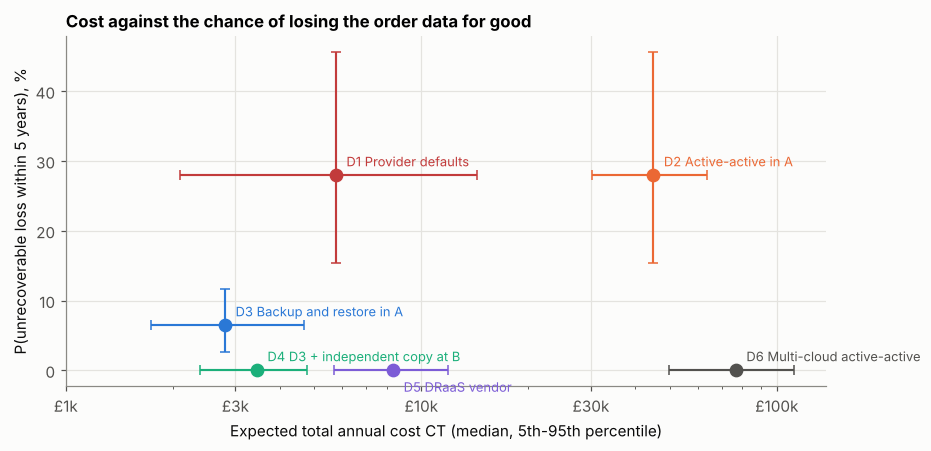

In [16]:
fig, ax = plt.subplots(figsize=(8.6, 4.2))
cols = dict(D1=RED, D2=ORANGE, D3=BLUE, D4=AQUA, D5=VIOLET, D6=INK)
for d in designs.index:
    x, y = R[d]["total"], R[d]["p_unrec_5y"] * 100
    ax.errorbar(np.median(x), np.median(y), xerr=[[np.median(x) - np.quantile(x, .05)], [np.quantile(x, .95) - np.median(x)]],
                yerr=[[np.median(y) - np.quantile(y, .05)], [np.quantile(y, .95) - np.median(y)]],
                fmt="o", color=cols[d], ms=8, capsize=3, lw=1.4)
    ax.annotate(f"{d} {designs.design[d]}", (np.median(x), np.median(y)), xytext=(7, -14 if d == "D5" else 6), textcoords="offset points",
                fontsize=8.5, color=cols[d])
ax.set_xscale("log"); ax.set_xticks([1_000, 3_000, 10_000, 30_000, 100_000], ["£1k", "£3k", "£10k", "£30k", "£100k"])
ax.set_xlabel("Expected total annual cost CT (median, 5th-95th percentile)")
ax.set_ylabel("P(unrecoverable loss within 5 years), %")
ax.set_title("Cost against the chance of losing the order data for good", loc="left")
fig.tight_layout()
fig.savefig("figures/u10_cost_risk.png", dpi=150, bbox_inches="tight")

### 6.3 Where the remaining breaches come from

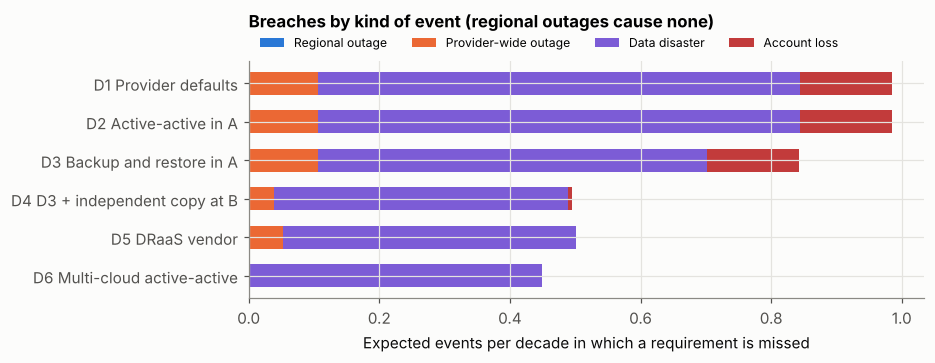

In [17]:
fig, ax = plt.subplots(figsize=(8.6, 3.4))
left = np.zeros(len(designs))
ev_cols = dict(E1=BLUE, E2=ORANGE, E3=VIOLET, E4=RED)
for e in EVENTS:
    vals = np.array([R[d][f"breach_{e}"].mean() * 10 for d in designs.index])
    ax.barh(range(len(designs)), vals, left=left, color=ev_cols[e], label=EVENTS[e], height=0.6)
    left += vals
ax.set_yticks(range(len(designs)), [f"{d} {designs.design[d]}" for d in designs.index]); ax.invert_yaxis()
ax.set_xlabel("Expected events per decade in which a requirement is missed")
ax.legend(ncol=4, fontsize=8, loc="lower left", bbox_to_anchor=(0, 1.0), frameon=False)
ax.set_title("Breaches by kind of event (regional outages cause none)", loc="left", pad=22)
fig.tight_layout()
fig.savefig("figures/u10_breaches.png", dpi=150, bbox_inches="tight")

Three things stand out. Regional outages never breach the requirements in any design, because a 36-hour RTO can simply wait them out; the executive summary's second region of A buys protection against the one event that did not need it. The provider-wide outage and the loss of the account are common-cause events: they take out every region of A together, which is the statistical dependence that Alhazmi and Malaiya say needs modelling but leave out. Only designs with something outside A (D4, D5 and D6) cover them. Data disasters dominate what is left in every design, including the most expensive.

## 7. Detection: the requirement no design meets on its own

An RPO for data disasters is not only a matter of how often backups are taken. Corruption or deletion is often noticed late, and every hour between the damage and its discovery is lost or has to be re-entered, whatever the backup interval. With a detection delay of up to three days, even D6 misses the 24-hour RPO in about half of data disasters. The mission thread suggests a cheap control: reconcile the day's orders in the shop against the payment provider's records every working day, so missing or altered orders are found within about a day.

In [18]:
recon_det = np.minimum(ev.E3_detect.values, tri_q(U["t5"], 1, 12, 26))
RECON_COST = tri_q(U["retry"], 1, 2, 3) * b.day_rate.values     # a script plus a two-minute check each working day
R_recon = {d: evaluate(d, recon_det) for d in designs.index}
t = pd.DataFrame({
    "Data disasters meeting R1 and R3, now %": [R[d]["meet_E3"].mean() * 100 for d in designs.index],
    "with daily reconciliation %": [R_recon[d]["meet_E3"].mean() * 100 for d in designs.index],
    "Breaches per decade, now": [R[d]["breaches"].mean() * 10 for d in designs.index],
    "with reconciliation": [R_recon[d]["breaches"].mean() * 10 for d in designs.index],
}, index=[f"{d} {designs.design[d]}" for d in designs.index])
print(t.round(2).to_string())
saving = R["D4"]["cd"] - R_recon["D4"]["cd"]
print(f"\nReconciliation costs a median £{np.median(RECON_COST):,.0f} a year and saves D4 a median £{np.median(saving):,.0f} in expected disaster cost")

                               Data disasters meeting R1 and R3, now %  with daily reconciliation %  Breaches per decade, now  with reconciliation
D1 Provider defaults                                             20.84                        39.93                      0.98                 0.81
D2 Active-active in A                                            20.84                        39.93                      0.98                 0.81
D3 Backup and restore in A                                       36.07                        72.50                      0.84                 0.50
D4 D3 + independent copy at B                                    51.87                        99.47                      0.50                 0.05
D5 DRaaS vendor                                                  52.00                        99.50                      0.50                 0.06
D6 Multi-cloud active-active                                     52.00                        99.50                   

Reconciliation does not pay for itself in expected losses, because a lost hour of order data is cheap when most paid orders can be re-keyed. It is, however, the only way the data-disaster RPO becomes achievable, and with it D4 is expected to miss a requirement about once in two hundred years. Whether a 24-hour RPO for data disasters is worth about £800 a year is a decision for the owner, and the model makes that trade-off visible instead of hiding it in a tier name.

## 8. Equation 3 as printed

Section 1.2 argued that Equation 3 as printed cannot see the benefit of being able to recover. The full model shows what that does to the decision.

In [19]:
tp = pd.DataFrame({d: R[d]["total_printed"] for d in designs.index})
cmp = pd.DataFrame({
    "Median CT, Eq. 3 as printed": tp.median(),
    "Median CT, corrected": tot.median(),
    "Cheapest %, as printed": (tp.idxmin(axis=1).value_counts(normalize=True) * 100).reindex(designs.index).fillna(0),
    "Cheapest %, corrected": (tot.idxmin(axis=1).value_counts(normalize=True) * 100).reindex(designs.index).fillna(0),
})
cmp.index = [f"{d} {designs.design[d]}" for d in designs.index]
print(cmp.round(1).to_string())

                               Median CT, Eq. 3 as printed  Median CT, corrected  Cheapest %, as printed  Cheapest %, corrected
D1 Provider defaults                               55666.4                5743.9                    99.9                    6.6
D2 Active-active in A                              95286.6               44896.3                     0.0                    0.0
D3 Backup and restore in A                         56892.1                2801.5                     0.1                   69.8
D4 D3 + independent copy at B                      58683.3                3443.9                     0.0                   23.5
D5 DRaaS vendor                                    63474.7                8321.1                     0.0                    0.0
D6 Multi-cloud active-active                      135758.4               76601.6                     0.0                    0.0


Read literally, the equation multiplies the expected cost of disasters roughly tenfold and recommends the provider defaults, the design with no independent copy, in almost every input set. The corrected version ranks D3 and D4 first.

## 9. Result

| Requirement | D4 with daily reconciliation |
|---|---|
| R1 RTO 36 h | Wait for the provider up to the latest safe start (24 h for a region of A, 12 h for the whole of A), then restore in a second region of A or rebuild at B |
| R2 RPO 15 min (infrastructure) | Hourly copies in A suffice for a regional outage, which is waited out; exports to B every 15 minutes cover a provider-wide outage or account loss |
| R3 RPO 24 h (data disasters) | Daily reconciliation against the payment provider's records to catch damage within about a day; immutable daily copy in A, copy at B every 15 minutes |
| R4 copy admin credentials cannot delete | Vault copy locked in A; the copy at B is under separate credentials, with its own MFA and a break-glass account not held by A |
| R5 restore tested | Rebuild at B from infrastructure as code twice a year; this is also an exit rehearsal |
| Design rules from the mission thread | Domain and DNS kept with the registrar, outside A; supplier phone list and the order reconciliation report kept outside A |

D4 is not the cheapest design on expected cost; D3 is cheaper in about 70% of input sets, by a median of about £670 a year. What the extra money buys is the tail: D3 leaves a median 6% chance of losing the order data for good within five years, through the loss of the account, while D4 brings it close to zero. Expected cost alone, which is the only output Alhazmi and Malaiya's framework produces, would not show that difference. D5 meets the requirements about as well as D4 but at more than twice the cost, adds another supplier with access to all the data, and in half the input sets runs on provider A itself. The executive summary's active-active design (D2) costs about £45,000 a year and leaves the chance of an unrecoverable loss exactly where the provider defaults leave it.

## References

Alhazmi, O.H. and Malaiya, Y.K. (2013) ‘Evaluating disaster recovery plans using the cloud’, *2013 Proceedings Annual Reliability and Maintainability Symposium (RAMS)*. IEEE, pp. 1–6. Available at: https://www.cs.colostate.edu/~malaiya/p/DisasterRecovery2013.pdf (Accessed: 3 October 2026).

AWS (2025) *Summary of the Amazon DynamoDB service disruption in the Northern Virginia (US-EAST-1) Region*. Seattle, WA: Amazon Web Services. Available at: https://aws.amazon.com/message/101925/ (Accessed: 3 October 2026).

Corbari, G.I., Khatod, N., Popiak, J.F. and Sinclair, P. (2024) ‘Mission thread analysis: establishing a common framework in a multi-discipline domain to enhance defensive cyberspace operations’, *The Cyber Defense Review*, 9(1), pp. 37–54. Available at: https://www.jstor.org/stable/48770663 (Accessed: 3 October 2026).

Google Cloud (2024) ‘Details of Google Cloud GCVE incident’, *Google Cloud blog*, 24 May. Available at: https://cloud.google.com/blog/products/infrastructure/details-of-google-cloud-gcve-incident (Accessed: 3 October 2026).

Group 2 (2025) *A risk assessment report for Pampered Pets based on ISO/IEC 27005:2022 and ISO 31000:2018*. Unpublished team report, Security and Risk Management module. University of Essex Online.

Kumar, A. (2024) *Cloud vendor lock-in: identify, strategies and mitigate*. Seminar paper, supervised by F. Waldhofer and H. Wehnes, 10 September. OSSBIG Austria. Available at: https://www.ossbig.at/wp-content/uploads/2024/09/CAN_Final_Report-VendorLock-In.pdf (Accessed: 3 October 2026).

Microsoft (2024) ‘Helping our customers through the CrowdStrike outage’, *The Official Microsoft Blog*, 20 July. Available at: https://blogs.microsoft.com/blog/2024/07/20/helping-our-customers-through-the-crowdstrike-outage/ (Accessed: 3 October 2026).

National Cyber Security Centre (NCSC) (2019) ‘Offline backups in an online world’, *NCSC blog*, 13 August. Available at: https://www.ncsc.gov.uk/blog-post/offline-backups-in-an-online-world (Accessed: 3 October 2026).

Stevens, I. (2026) *Quantitative risk assessment and digital resilience strategy for Pampered Pets: executive summary*. Unpublished assignment, Security and Risk Management module. University of Essex Online.

UniSuper and Google Cloud (2024) ‘A joint statement from UniSuper and Google Cloud’, *UniSuper media centre*, 8 May. Available at: https://www.unisuper.com.au/about-us/media-centre/2024/a-joint-statement-from-unisuper-and-google-cloud (Accessed: 3 October 2026).

Wiboonratr and Kosavisutte (2009) is cited as it appears in Alhazmi and Malaiya (2013).